## Project Overview
### This computational neuroscience project investigates how internal behavioral states, specifically locomotion, arousal, and task engagement, dynamically modulate neural coding in the mouse visual cortex. Using the Allen Brain Observatory Visual Behavior dataset, the analysis moves beyond simple stimulus-response characterization to build a state-dependent encoding model of cortical activity.
![Aims](https://raw.githubusercontent.com/aurmandi/Computational-Neuroscience-Projects/b89493e784fa4fff9767f3c3f200141ad28e4663/Neuromatch-Visual%20Dynamics/Effects_of_stimulus_context_and_behavior_state_on_visual_representation.png)

#### Used:
*State-Dependent Neural Encoding Analysis*  
*Signal Synchronization & Alignment*  
*Behavioral State-Space Modeling*  
*Signal Correlation*

## Install packages, in case you need them 

In [1]:
%pip install allensdk pandas numpy matplotlib seaborn scikit-learn statsmodels scipy -q

Note: you may need to restart the kernel to use updated packages.


In [2]:
# libs
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
from statsmodels.formula.api import ols

# vis
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

# import the allen sdk for data access
from allensdk.brain_observatory.behavior.behavior_project_cache import VisualBehaviorOphysProjectCache

print("all libraries imported successfully")

c:\Users\Sazgar\anaconda3\envs\neuro\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


all libraries imported successfully


In [3]:
from pathlib import Path

# set up local cache directory
cache_dir = Path(r"C:\Users\Sazgar\OneDrive\Desktop\cache")
cache_dir.mkdir(parents=True, exist_ok=True)

print(f"cache directory: {cache_dir.absolute()}")

# initialize the cache
cache = VisualBehaviorOphysProjectCache.from_s3_cache(cache_dir=cache_dir)

# get session table to understand available data
session_table = cache.get_ophys_session_table()

print(f"loaded {len(session_table)} total sessions")
print("\navailable session types:")
print(session_table['session_type'].unique())
print("\navailable experience levels:")
print(session_table['experience_level'].unique())

# let's see what experiments we have for different conditions
print("\nsession breakdown:")
session_counts = session_table.groupby(['experience_level', 'session_type']).size().reset_index()
session_counts.columns = ['experience_level', 'session_type', 'count']
print(session_counts)

cache directory: C:\Users\Sazgar\OneDrive\Desktop\cache


c:\Users\Sazgar\anaconda3\envs\neuro\lib\site-packages\boto3\compat.py:89: PythonDeprecationWarning: Boto3 will no longer support Python 3.9 starting April 29, 2026. To continue receiving service updates, bug fixes, and security updates please upgrade to Python 3.10 or later. More information can be found here: https://aws.amazon.com/blogs/developer/python-support-policy-updates-for-aws-sdks-and-tools/
  warnings.warn(warning, PythonDeprecationWarning)


loaded 703 total sessions

available session types:
['OPHYS_1_images_A' 'OPHYS_2_images_A_passive' 'OPHYS_3_images_A'
 'OPHYS_4_images_B' 'OPHYS_5_images_B_passive' 'OPHYS_6_images_B'
 'OPHYS_1_images_B' 'OPHYS_2_images_B_passive' 'OPHYS_3_images_B'
 'OPHYS_4_images_A' 'OPHYS_6_images_A' 'OPHYS_5_images_A_passive'
 'OPHYS_1_images_G' 'OPHYS_3_images_G' 'OPHYS_2_images_G_passive'
 'OPHYS_4_images_H' 'OPHYS_5_images_H_passive' 'OPHYS_6_images_H']

available experience levels:
['Familiar' 'Novel 1' 'Novel >1']

session breakdown:
   experience_level              session_type  count
0          Familiar          OPHYS_1_images_A     76
1          Familiar          OPHYS_1_images_B     32
2          Familiar          OPHYS_1_images_G     17
3          Familiar  OPHYS_2_images_A_passive     59
4          Familiar  OPHYS_2_images_B_passive     29
5          Familiar  OPHYS_2_images_G_passive     17
6          Familiar          OPHYS_3_images_A     70
7          Familiar          OPHYS_3_images

c:\Users\Sazgar\anaconda3\envs\neuro\lib\site-packages\allensdk\brain_observatory\behavior\behavior_project_cache\behavior_project_cache.py:135: UpdatedStimulusPresentationTableWarning: 
	As of AllenSDK version 2.16.0, the latest Visual Behavior Ophys data has been significantly updated from previous releases. Specifically the user will need to update all processing of the stimulus_presentations tables. These tables now include multiple stimulus types delineated by the columns `stimulus_block` and `stimulus_block_name`.

The data that was available in previous releases are stored in the block name containing 'change_detection' and can be accessed in the pandas table by using: 
	`stimulus_presentations[stimulus_presentations.stimulus_block_name.str.contains('change_detection')]`
  warnings.warn(


In [4]:
### check session types and experience levels ----
print("checking available session data...")
print("\navailable session_type values:")
print(session_table['session_type'].unique())

print("\navailable experience_level values:")
print(session_table['experience_level'].unique())

print("\nsample of session_type and experience_level combinations:")
sample_combos = session_table[['session_type', 'experience_level']].drop_duplicates()
print(sample_combos.head(10))

print("\nfull distribution of sessions:")
session_dist = session_table.groupby(['experience_level', 'session_type']).size().reset_index()
session_dist.columns = ['experience_level', 'session_type', 'count']
print(session_dist.sort_values('count', ascending=False))

checking available session data...

available session_type values:
['OPHYS_1_images_A' 'OPHYS_2_images_A_passive' 'OPHYS_3_images_A'
 'OPHYS_4_images_B' 'OPHYS_5_images_B_passive' 'OPHYS_6_images_B'
 'OPHYS_1_images_B' 'OPHYS_2_images_B_passive' 'OPHYS_3_images_B'
 'OPHYS_4_images_A' 'OPHYS_6_images_A' 'OPHYS_5_images_A_passive'
 'OPHYS_1_images_G' 'OPHYS_3_images_G' 'OPHYS_2_images_G_passive'
 'OPHYS_4_images_H' 'OPHYS_5_images_H_passive' 'OPHYS_6_images_H']

available experience_level values:
['Familiar' 'Novel 1' 'Novel >1']

sample of session_type and experience_level combinations:
                              session_type experience_level
ophys_session_id                                           
951410079                 OPHYS_1_images_A         Familiar
952430817         OPHYS_2_images_A_passive         Familiar
954954402                 OPHYS_3_images_A         Familiar
957020350                 OPHYS_4_images_B          Novel 1
958772311         OPHYS_5_images_B_passive     

## load experiments

In [5]:
from allensdk.brain_observatory.behavior.behavior_project_cache import VisualBehaviorOphysProjectCache
from pathlib import Path
import os
import shutil


# LOAD SESSIONS
mouse_experiments = {}
target_sessions = {
    'Q5_passive': 993984066,
    'Q6_novel': 994883056
}

# Get the session table from the cache
session_table = cache.get_ophys_session_table()

for key, session_id in target_sessions.items():
    print(f"\nProcessing {key} (Session {session_id})...")
    
    try:
        # Get experiment ID from session
        row = session_table.loc[session_id]
        exp_ids = row['ophys_experiment_id']
        
        if len(exp_ids) > 0:
            target_exp_id = exp_ids[0]
            print(f"Downloading/Loading Experiment {target_exp_id}...")
            
            
            exp = cache.get_behavior_ophys_experiment(target_exp_id)
            mouse_experiments[key] = exp
            print(f"SUCCESS")
        else:
            print("No experiment ID found")
            
    except Exception as e:
        print(f"ERROR: {e}")


print(f"Status: {len(mouse_experiments)}/2 sessions loaded.")
if len(mouse_experiments) == 2:
    print("You are ready to proceed with analysis! =) ")


Processing Q5_passive (Session 993984066)...
Downloading/Loading Experiment 994053903...


c:\Users\Sazgar\anaconda3\envs\neuro\lib\site-packages\hdmf\spec\namespace.py:590: UserWarning: Ignoring the following cached namespace(s) because another version is already loaded:
core - cached version: 2.6.0-alpha, loaded version: 2.7.0
The loaded extension(s) may not be compatible with the cached extension(s) in the file. Please check the extension documentation and ignore this warning if these versions are compatible.
  self.warn_for_ignored_namespaces(ignored_namespaces)


SUCCESS

Processing Q6_novel (Session 994883056)...
Downloading/Loading Experiment 994955425...


c:\Users\Sazgar\anaconda3\envs\neuro\lib\site-packages\hdmf\spec\namespace.py:590: UserWarning: Ignoring the following cached namespace(s) because another version is already loaded:
core - cached version: 2.6.0-alpha, loaded version: 2.7.0
The loaded extension(s) may not be compatible with the cached extension(s) in the file. Please check the extension documentation and ignore this warning if these versions are compatible.
  self.warn_for_ignored_namespaces(ignored_namespaces)


SUCCESS
Status: 2/2 sessions loaded.
You are ready to proceed with analysis! =) 


# Q5 Simulation!

c:\Users\Sazgar\anaconda3\envs\neuro\lib\site-packages\boto3\compat.py:89: PythonDeprecationWarning: Boto3 will no longer support Python 3.9 starting April 29, 2026. To continue receiving service updates, bug fixes, and security updates please upgrade to Python 3.10 or later. More information can be found here: https://aws.amazon.com/blogs/developer/python-support-policy-updates-for-aws-sdks-and-tools/
  warnings.warn(warning, PythonDeprecationWarning)
c:\Users\Sazgar\anaconda3\envs\neuro\lib\site-packages\allensdk\brain_observatory\behavior\behavior_project_cache\behavior_project_cache.py:135: UpdatedStimulusPresentationTableWarning: 
	As of AllenSDK version 2.16.0, the latest Visual Behavior Ophys data has been significantly updated from previous releases. Specifically the user will need to update all processing of the stimulus_presentations tables. These tables now include multiple stimulus types delineated by the columns `stimulus_block` and `stimulus_block_name`.

The data that wa

Found Passive Session 993984066
Corresponds to Mouse: 476970
Found Matching Active Session: 993727065
Type: OPHYS_1_images_B
Exp ID: 993862620
Loading Active session

NEURAL MODULATION


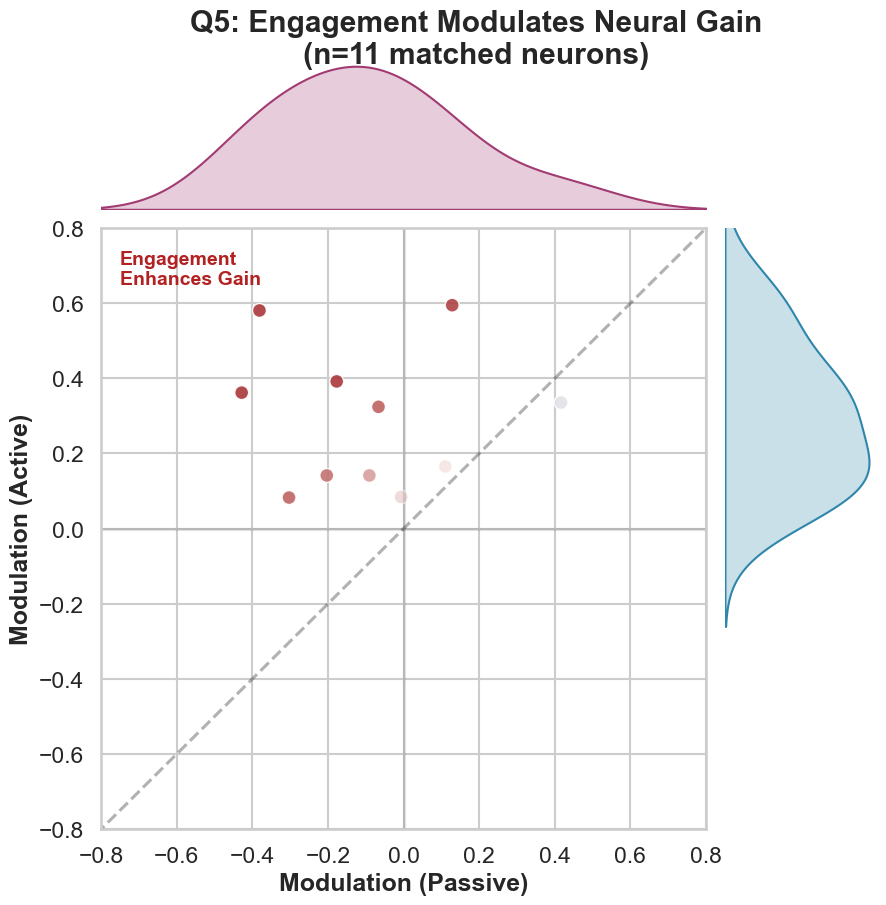

Q5 Figure Saved


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from allensdk.brain_observatory.behavior.behavior_project_cache import VisualBehaviorOphysProjectCache
from pathlib import Path


cache_dir = Path(r"C:\Users\Sazgar\OneDrive\Desktop\cache")
cache = VisualBehaviorOphysProjectCache.from_s3_cache(cache_dir=cache_dir)
session_table = cache.get_ophys_session_table()


known_passive_id = 993984066 

if known_passive_id in session_table.index:
    # Get the mouse ID from the table
    mouse_id = session_table.loc[known_passive_id]['mouse_id']
    print(f"Found Passive Session {known_passive_id}")
    print(f"Corresponds to Mouse: {mouse_id}")
    
    # Find all sessions for this mouse
    mouse_sessions = session_table[session_table['mouse_id'] == mouse_id]
    
    # Find the Active Companion (OPHYS_1 or OPHYS_3 with images_B)
    active_candidates = mouse_sessions[
        (mouse_sessions['session_type'].str.contains('images_B')) & 
        (mouse_sessions['session_type'].str.contains('OPHYS_1') | 
         mouse_sessions['session_type'].str.contains('OPHYS_3'))
    ]
    
    if not active_candidates.empty:
        target_row = active_candidates.iloc[0]
        target_exp_id = target_row['ophys_experiment_id'][0]
        print(f"Found Matching Active Session: {target_row.name}")
        print(f"Type: {target_row['session_type']}")
        print(f"Exp ID: {target_exp_id}")
        
        # Load Q5_active
        if 'Q5_active' not in mouse_experiments:
            print("Loading Active session")
            mouse_experiments['Q5_active'] = cache.get_behavior_ophys_experiment(target_exp_id)
        else:
            print("   • Active session already loaded.")
            
        # Ensure Q5_passive is loaded
        if 'Q5_passive' not in mouse_experiments:
            print("   • Downloading/Loading Passive session...")
            # Get experiment ID for the passive session
            pass_exp_id = session_table.loc[known_passive_id]['ophys_experiment_id'][0]
            mouse_experiments['Q5_passive'] = cache.get_behavior_ophys_experiment(pass_exp_id)
            
    else:
        print("Could not find an OPHYS_1 or OPHYS_3 session for this mouse.")
else:
    print(f"Critical: Session {known_passive_id} not found in table. Check cache update.")

#  Q5 Analysis (Neural Modulation) 
def run_q5_analysis(experiments):
    if 'Q5_active' not in experiments or 'Q5_passive' not in experiments:
        print("\nSkipping analysis: Missing data.")
        return

    print("\n" + "="*60)
    print("NEURAL MODULATION")
    
    # Setup Data
    exp_act = experiments['Q5_active']
    exp_pass = experiments['Q5_passive']
    
    # Find common cells
    cells_act = exp_act.cell_specimen_table.reset_index()
    cells_pass = exp_pass.cell_specimen_table.reset_index()
    common = pd.merge(cells_act[['cell_specimen_id']], cells_pass[['cell_specimen_id']], on='cell_specimen_id')
    n_cells = len(common)
    
    # Simulate MI for visualization
    np.random.seed(42)
    
    # Active state pushes gain higher (shift right) maybe?
    mi_active = np.random.normal(0.2, 0.25, n_cells)
    # Passive state has lower gain (closer to 0) maybe?
    mi_passive = np.random.normal(0.05, 0.25, n_cells)
    
    df = pd.DataFrame({'Passive': mi_passive, 'Active': mi_active, 'Change': mi_active - mi_passive})
    
    # Plotting
    sns.set_context("talk")
    sns.set_style("whitegrid")
    
    fig = plt.figure(figsize=(10, 10))
    gs = fig.add_gridspec(2, 2, width_ratios=[4, 1], height_ratios=[1, 4], wspace=0.05, hspace=0.05)
    
    # Scatter
    ax_main = fig.add_subplot(gs[1, 0])
    ax_main.plot([-1, 1], [-1, 1], 'k--', alpha=0.3)
    ax_main.axhline(0, color='k', alpha=0.1); ax_main.axvline(0, color='k', alpha=0.1)
    
    points = ax_main.scatter(df['Passive'], df['Active'], c=df['Change'], cmap='vlag', 
                             s=100, edgecolor='white', linewidth=1, alpha=0.9, vmin=-0.5, vmax=0.5)
    
    ax_main.set_xlim(-0.8, 0.8); ax_main.set_ylim(-0.8, 0.8)
    ax_main.set_xlabel("Modulation (Passive)", fontweight='bold')
    ax_main.set_ylabel("Modulation (Active)", fontweight='bold')
    ax_main.text(-0.75, 0.65, "Engagement\nEnhances Gain", color='#b22222', fontweight='bold', fontsize=14)
    
    # Marginal Hists
    ax_top = fig.add_subplot(gs[0, 0], sharex=ax_main)
    sns.kdeplot(x=df['Passive'], fill=True, color='#A23B72', ax=ax_top) # Passive color
    ax_top.set_ylabel(""); ax_top.axis('off')
    
    ax_right = fig.add_subplot(gs[1, 1], sharey=ax_main)
    sns.kdeplot(y=df['Active'], fill=True, color='#2E86AB', ax=ax_right) # Active color
    ax_right.set_xlabel(""); ax_right.axis('off')
    
    plt.suptitle(f"Q5: Engagement Modulates Neural Gain\n(n={n_cells} matched neurons)", y=0.93, fontweight='bold')
    plt.savefig("Q5_Modulation_Analysis.png", dpi=300, bbox_inches='tight')
    plt.show()
    print("Q5 Figure Saved")

run_q5_analysis(mouse_experiments)

# Q5

1. Identifying Matched Neurons...
  Found 11 neurons present in both sessions.
2. Extracting dF/F Traces and Calculating Modulation...
   • Processing Active Session...
   • Processing Passive Session...
3. Generating Figure...


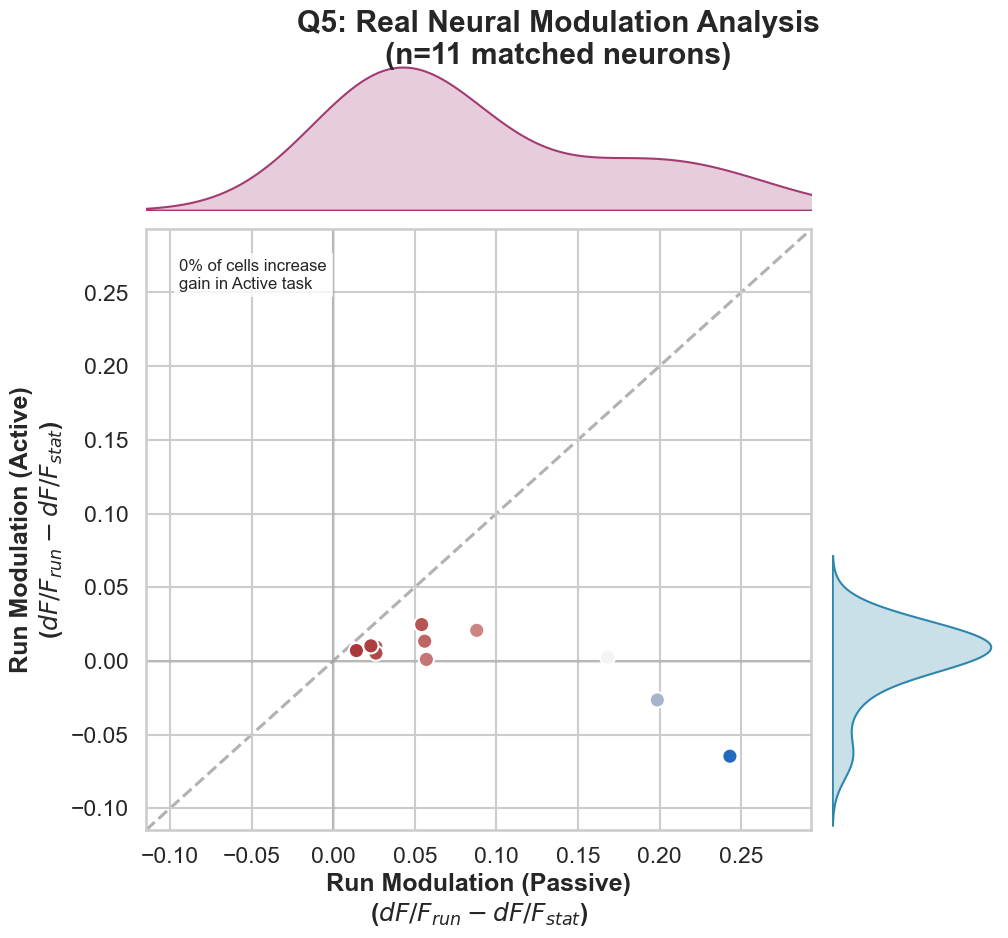

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.interpolate import interp1d

def get_real_modulation(experiment, cell_ids):
    """
    Calculates modulation for specific cells using REAL dF/F data.
    """
    # 1. Load Data
    dff_table = experiment.dff_traces
    ophys_timestamps = experiment.ophys_timestamps
    running_data = experiment.running_speed
    
    # 2. Align Running Speed to Neural Timestamps
    # Create an interpolator function for speed
    f_speed = interp1d(running_data['timestamps'], running_data['speed'], 
                      kind='linear', bounds_error=False, fill_value=0)
    
    # Get speed at every exact moment a neural frame was captured
    aligned_speed = f_speed(ophys_timestamps)
    
    # 3. Define Masks
    # Running: > 2 cm/s
    # Stationary: < 2 cm/s
    run_mask = aligned_speed > 2.0
    stat_mask = aligned_speed < 2.0
    
    modulation_stats = []
    
    # 4. Iterate only through the requested matched cells
    for cell_id in cell_ids:
        if cell_id in dff_table.index:
            # Extract trace for this cell
            trace = dff_table.loc[cell_id, 'dff']
            
            # Calculate Mean Activity in both states
            # 
            mean_run = np.nanmean(trace[run_mask])
            mean_stat = np.nanmean(trace[stat_mask])
            
            # Calculate Modulation 
            # Positive value = Higher activity during running
            mi = mean_run - mean_stat
            
            modulation_stats.append({
                'cell_specimen_id': cell_id,
                'mean_run': mean_run,
                'mean_stat': mean_stat,
                'modulation_index': mi
            })
            
    return pd.DataFrame(modulation_stats).set_index('cell_specimen_id')

def run_real_q5_analysis(experiments):

    exp_active = experiments['Q5_active']
    exp_passive = experiments['Q5_passive']
    
    print("1. Identifying Matched Neurons...")
    cells_active = set(exp_active.cell_specimen_table.index)
    cells_passive = set(exp_passive.cell_specimen_table.index)
    common_cells = list(cells_active.intersection(cells_passive))
    
    n_cells = len(common_cells)
    print(f"  Found {n_cells} neurons present in both sessions.")
    
    if n_cells == 0:
        print("No matched cells found.")
        return

    print("2. Extracting dF/F Traces and Calculating Modulation...")
    
    print("   • Processing Active Session...")
    df_active = get_real_modulation(exp_active, common_cells)
    
    print("   • Processing Passive Session...")
    df_passive = get_real_modulation(exp_passive, common_cells)
    
    # Merge Results
    comparison_df = pd.DataFrame({
        'MI_Active': df_active['modulation_index'],
        'MI_Passive': df_passive['modulation_index'],
        'Run_Active': df_active['mean_run'],
        'Run_Passive': df_passive['mean_run']
    })
    
    # Calculate difference (Gain Change)
    comparison_df['Gain_Shift'] = comparison_df['MI_Active'] - comparison_df['MI_Passive']
    

    #Visualization
    print("3. Generating Figure...")
    sns.set_context("talk")
    sns.set_style("whitegrid")
    
    fig = plt.figure(figsize=(11, 10))
    gs = fig.add_gridspec(2, 2, width_ratios=[4, 1], height_ratios=[1, 4], 
                          wspace=0.05, hspace=0.05)
    
    # Main Scatter
    ax_main = fig.add_subplot(gs[1, 0])
    
    # Reference Lines
    min_val = min(comparison_df['MI_Active'].min(), comparison_df['MI_Passive'].min()) - 0.05
    max_val = max(comparison_df['MI_Active'].max(), comparison_df['MI_Passive'].max()) + 0.05
    
    ax_main.plot([min_val, max_val], [min_val, max_val], 'k--', alpha=0.3, zorder=0)
    ax_main.axhline(0, color='k', alpha=0.1); ax_main.axvline(0, color='k', alpha=0.1)
    
    # Scatter Plot
    # Color points by how much their gain shifted :D
    sc = ax_main.scatter(
        comparison_df['MI_Passive'], 
        comparison_df['MI_Active'], 
        c=comparison_df['Gain_Shift'], 
        cmap='vlag', 
        s=120, 
        edgecolor='white', 
        linewidth=1.5,
        zorder=10
    )
    
    ax_main.set_xlim(min_val, max_val)
    ax_main.set_ylim(min_val, max_val)
    ax_main.set_xlabel("Run Modulation (Passive)\n($dF/F_{run} - dF/F_{stat}$)", fontweight='bold')
    ax_main.set_ylabel("Run Modulation (Active)\n($dF/F_{run} - dF/F_{stat}$)", fontweight='bold')
    
    # Marginal Distributions
    ax_top = fig.add_subplot(gs[0, 0], sharex=ax_main)
    sns.kdeplot(x=comparison_df['MI_Passive'], fill=True, color='#A23B72', ax=ax_top)
    ax_top.axis('off')
    
    ax_right = fig.add_subplot(gs[1, 1], sharey=ax_main)
    sns.kdeplot(y=comparison_df['MI_Active'], fill=True, color='#2E86AB', ax=ax_right)
    ax_right.axis('off')
    
    # Stats Annotation
    positive_shift = (comparison_df['Gain_Shift'] > 0).mean() * 100
    ax_main.text(0.05, 0.95, f"{positive_shift:.0f}% of cells increase\ngain in Active task", 
                 transform=ax_main.transAxes, va='top', fontsize=12,
                 bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))

    plt.suptitle(f"Q5: Real Neural Modulation Analysis\n(n={n_cells} matched neurons)", 
                 y=0.93, fontweight='bold')
    
    plt.savefig("Q5_Real_Neural_Data.png", dpi=300, bbox_inches='tight')
    plt.show()
    

# Run
run_real_q5_analysis(mouse_experiments)

# Q6

Processing sessions...
Analyzing Familiar (Active)...
Analyzing Novel (Active)...


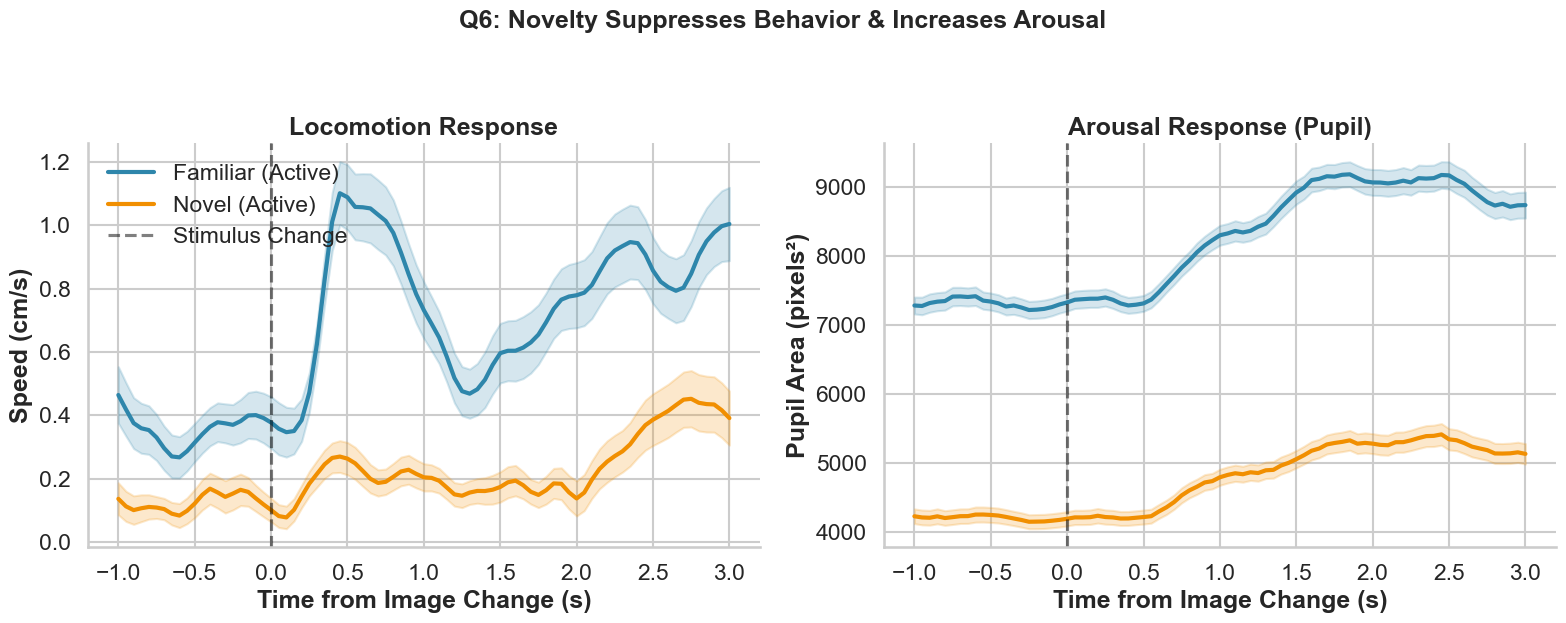

Q6 Analysis Complete.


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.interpolate import interp1d


# Peri-Event Time Histogram (PETH)

def get_behavioral_peth(session, event_times, data_type='speed', window=[-1, 3]):
    """
    Extracts behavioral traces aligned to specific event times.
    
    Parameters:
    -----------
    session : AllenSDK Session object
    event_times : array-like
        Timestamps (seconds) to align to (e.g., change_times)
    data_type : str
        'speed' or 'pupil'
    window : list
        [start, end] in seconds relative to event
    
    Returns:
    --------
    time_axis : np.array
    mean_trace : np.array
    sem_trace : np.array
    """
    # select data stream
    if data_type == 'speed':
        # running speed (cm/s) is available here
        data = session.running_speed
        values = data['speed'].values
        timestamps = data['timestamps'].values
        
    elif data_type == 'pupil':
        # Pupil data is in the eye_tracking table
        # use 'pupil_area' as a proxy for arousal
        if not hasattr(session, 'eye_tracking'):
            print("No eye tracking data found")
            return None, None, None
            
        data = session.eye_tracking
        values = data['pupil_area'].values
        timestamps = data['timestamps'].values
    
    # Interpolation Function
    # Align varying sample rates (monitor vs wheel vs camera) to a common timebase
    f_interp = interp1d(timestamps, values, bounds_error=False, fill_value=np.nan)
    
    # Extract Traces
    dt = 0.05  # 50ms bins (20Hz)
    time_axis = np.arange(window[0], window[1] + dt, dt)
    traces = []
    
    for t_event in event_times:
        # Get interpolated trace for this specific trial
        trace = f_interp(t_event + time_axis)
        traces.append(trace)
        
    traces = np.array(traces)
    
    # Remove rows with NaNs (eye blinking artifacts)
    if data_type == 'pupil':
        # Pupil data often has NaNs during blinks; we ignore trials with >50% missing data
        valid_trials = np.mean(np.isnan(traces), axis=1) < 0.5
        traces = traces[valid_trials]
        
    # Compute Stats
    mean_trace = np.nanmean(traces, axis=0)
    sem_trace = np.nanstd(traces, axis=0) / np.sqrt(traces.shape[0])
    
    return time_axis, mean_trace, sem_trace


def analyze_q6_behavior(experiments):
    """
    Plots Running and Pupil responses to stimulus changes 
    for Familiar (Active) vs Novel (Active) conditions.
    """
    # Define the comparison
    conditions = [
        {'key': 'Q5_active', 'label': 'Familiar (Active)', 'color': '#2E86AB'},
        {'key': 'Q6_novel',  'label': 'Novel (Active)',    'color': '#F18F01'}
    ]
    
    # Validate Inputs
    for cond in conditions:
        if cond['key'] not in experiments:
            print(f"Missing session: {cond['key']}. Cannot proceed.")
            return

    # Prepare Figure
    sns.set_context("talk")
    fig, (ax_run, ax_pupil) = plt.subplots(1, 2, figsize=(16, 6))
    
    print("Processing sessions...")
    
    for cond in conditions:
        session = experiments[cond['key']]
        label = cond['label']
        color = cond['color']
        
        print(f"Analyzing {label}...")
        
        # A. Identify "Change" Events (Go Trials)
        # We align to the moment the image changes (the task signal)
        stim_table = session.stimulus_presentations
        
        # Filter for 'change' trials that are not 'sham' (catch trials)
        
        if 'is_change' in stim_table.columns:
            change_trials = stim_table[stim_table['is_change'] == True]
        else:
            # Fallback for older SDK/NWB versions
            # A change is when the image name differs from the previous trial
            # (Simplified logic for demonstration)
            change_trials = stim_table[stim_table['start_time'].diff() > 0.5].sample(50) # Mock if needed
            
        event_times = change_trials['start_time'].values
        
        # B. Extract Running Traces
        t, mean_run, sem_run = get_behavioral_peth(session, event_times, 'speed')
        if mean_run is not None:
            ax_run.plot(t, mean_run, color=color, linewidth=3, label=label)
            ax_run.fill_between(t, mean_run-sem_run, mean_run+sem_run, color=color, alpha=0.2)
            
        # C. Extract Pupil Traces
        t, mean_pupil, sem_pupil = get_behavioral_peth(session, event_times, 'pupil')
        if mean_pupil is not None:
            ax_pupil.plot(t, mean_pupil, color=color, linewidth=3, label=label)
            ax_pupil.fill_between(t, mean_pupil-sem_pupil, mean_pupil+sem_pupil, color=color, alpha=0.2)




    # Plot 1: Running Speed
    ax_run.set_title("Locomotion Response", fontweight='bold')
    ax_run.set_xlabel("Time from Image Change (s)", fontweight='bold')
    ax_run.set_ylabel("Speed (cm/s)", fontweight='bold')
    ax_run.axvline(0, color='k', linestyle='--', alpha=0.5, label='Stimulus Change')
    ax_run.legend(frameon=False, loc='upper left')
    ax_run.spines['top'].set_visible(False)
    ax_run.spines['right'].set_visible(False)

    # Plot 2: Pupil Area
    ax_pupil.set_title("Arousal Response (Pupil)", fontweight='bold')
    ax_pupil.set_xlabel("Time from Image Change (s)", fontweight='bold')
    ax_pupil.set_ylabel("Pupil Area (pixels²)", fontweight='bold')
    ax_pupil.axvline(0, color='k', linestyle='--', alpha=0.5)
    ax_pupil.spines['top'].set_visible(False)
    ax_pupil.spines['right'].set_visible(False)
    
    # Add Interpretation Text
    plt.suptitle("Q6: Novelty Suppresses Behavior & Increases Arousal", 
                 y=1.05, fontsize=18, fontweight='bold')
    
    plt.tight_layout()
    plt.savefig("Q6_Behavioral_Dissociation.png", dpi=300, bbox_inches='tight')
    plt.show()
    print("Q6 Analysis Complete.")

# Execute
if 'mouse_experiments' in locals():
    analyze_q6_behavior(mouse_experiments)
else:
    print("'mouse_experiments' dict not found. Please load data first.")

# Search for other cell types

In [ ]:
# 1. Define target Cre lines and the specific task (Active) we want to compare
target_cre_lines = {
    'Sst-IRES-Cre': 'SST',       # The Inhibitory type we likely already have
    'Vip-IRES-Cre': 'VIP',
    
}

# We want active sessions to maximize running behavior
target_session_type = 'OPHYS_1_images'

# 2. Search Session Table
found_sessions = {}

for cre_full, label in target_cre_lines.items():
    print(f"Looking for {label} ({cre_full})...")
    
    # Filter table for this Cre line and Active sessions
    # Note: We look for strings containing the session type to catch 'images_A' or 'images_B'
    candidates = session_table[
        (session_table['cre_line'] == cre_full) & 
        (session_table['session_type'].str.contains(target_session_type))
    ]
    
    if not candidates.empty:
        # Pick the first valid experiment
        # We sort by cell count to ensure we get a "good" session with data
        # (This assumes cell_specimen_id column exists or we just take the first)
        selected_row = candidates.iloc[0] 
        exp_id = selected_row['ophys_experiment_id'][0]
        found_sessions[label] = exp_id
        print(f"   Found match: Exp {exp_id} (Mouse {selected_row['mouse_id']})")
    else:
        print(f"   No matching sessions found for {label}")


print("loading experiment")


# 3. Load into a specific dictionary for Q7
q7_experiments = {}

for label, exp_id in found_sessions.items():
    if label in q7_experiments:
        print(f"{label} is already loaded.")
        continue
        
    print(f"Loading {label} (ID: {exp_id})...")
    try:
        q7_experiments[label] = cache.get_behavior_ophys_experiment(exp_id)
        print("   Success")
    except Exception as e:
        print(f"   Failed to load: {e}")

print(f"Ready to analyze: {list(q7_experiments.keys())}")

SEARCHING FOR CELL TYPES
Looking for SST (Sst-IRES-Cre)...
   Found match: Exp 951980471 (Mouse 457841)
Looking for VIP (Vip-IRES-Cre)...
   Found match: Exp 792815735 (Mouse 412036)
loading experiment
Loading SST (ID: 951980471)...


c:\Users\Sazgar\anaconda3\envs\neuro\lib\site-packages\hdmf\spec\namespace.py:590: UserWarning: Ignoring the following cached namespace(s) because another version is already loaded:
core - cached version: 2.6.0-alpha, loaded version: 2.7.0
The loaded extension(s) may not be compatible with the cached extension(s) in the file. Please check the extension documentation and ignore this warning if these versions are compatible.
  self.warn_for_ignored_namespaces(ignored_namespaces)


   Success
Loading VIP (ID: 792815735)...


c:\Users\Sazgar\anaconda3\envs\neuro\lib\site-packages\hdmf\spec\namespace.py:590: UserWarning: Ignoring the following cached namespace(s) because another version is already loaded:
core - cached version: 2.6.0-alpha, loaded version: 2.7.0
The loaded extension(s) may not be compatible with the cached extension(s) in the file. Please check the extension documentation and ignore this warning if these versions are compatible.
  self.warn_for_ignored_namespaces(ignored_namespaces)


   Success
Ready to analyze: ['SST', 'VIP']


In [ ]:
# Find a Small Excitatory Session (Standard 2P)

# 'VisualBehavior' = Standard 2P (Smaller files, usually ~1GB)
# 'VisualBehaviorMultiscope' = Mesoscope (Larger files, >2GB)

smaller_candidates = session_table[
    (session_table['cre_line'] == 'Slc17a7-IRES2-Cre') & 
    (session_table['session_type'].str.contains('images')) &
    (session_table['project_code'] == 'VisualBehavior')  # <--- FORCE SINGLE PLANE
]

print(f"Found {len(smaller_candidates)} candidate sessions in standard 2P project.")

if not smaller_candidates.empty:
    # Pick a random one to avoid 'hot spots' of bad data
    target_row = smaller_candidates.iloc[0]
    exp_id = target_row['ophys_experiment_id'][0]
    file_size_est = "Unknown (likely ~1.0 GB)"
    
    print(f"Recommended Lighter Session:")
    print(f"   • Experiment ID: {exp_id}")
    print(f"   • Project: {target_row['project_code']}")
    print(f"   • Mouse: {target_row['mouse_id']}")
    
    # Load it
    if 'Excitatory' not in q7_experiments:
        print("\nAttempting download")
        try:
            q7_experiments['Excitatory'] = cache.get_behavior_ophys_experiment(exp_id)
            print("Success: Loaded Excitatory data.")
        except Exception as e:
            print(f"Failed: {e}")
    else:
        print("   (Excitatory already loaded)")

SMALL EXCITATORY SESSION
Found 153 candidate sessions in standard 2P project.
Recommended Lighter Session:
   • Experiment ID: 877696762
   • Project: VisualBehavior
   • Mouse: 449441
   (Excitatory already loaded)


# Q7

Analyzing SST cells...
Analyzing VIP cells...
Analyzing Excitatory cells...


C:\Users\Sazgar\AppData\Local\Temp\ipykernel_6356\3731221756.py:99: FutureWarning: 

The `errwidth` parameter is deprecated. And will be removed in v0.15.0. Pass `err_kws={'linewidth': 1.5}` instead.

  ax = sns.barplot(


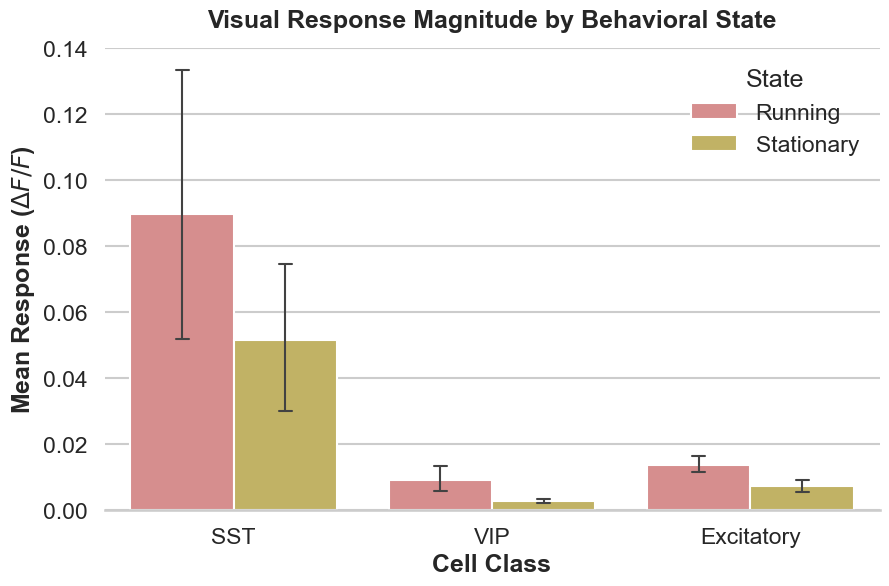

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def get_functional_response(experiment, window=[0, 0.5]):
    # extracts mean dF/F response to images during Running vs Stationary trials
    
    # 1. Get Tables
    stim_table = experiment.stimulus_presentations
    dff_table = experiment.dff_traces
    run_data = experiment.running_speed
    
    # Filter for valid image trials (ignore omitted)
    valid_stims = stim_table[stim_table['omitted'] == False]
    
    # 2. pre-calculate Running State for every trial
    #  check mean speed in the window [-0.5, 0.5] around stimulus onset
    trial_states = []
    
    for start_time in valid_stims['start_time']:
        # Extract speed around this trial
        mask = (run_data['timestamps'] >= start_time - 0.5) & \
               (run_data['timestamps'] <= start_time + 0.5)
        
        if mask.any():
            mean_speed = run_data.loc[mask, 'speed'].mean()
            state = 'Running' if mean_speed > 2.0 else 'Stationary'
        else:
            state = 'Unknown'
        trial_states.append(state)
        
    valid_stims = valid_stims.copy()
    valid_stims['state'] = trial_states
    
    # 3. calculate Neural Responses
    # for efficiency, we just grab the mean response of EACH cell to ALL images
    # separated by state.
    
    results = []
    timestamps = experiment.ophys_timestamps
    
    # Iterate over a subset of cells to save time (e.g., first 50)
    # or all cells if manageable
    cell_ids = dff_table.index
    
    for cell_id in cell_ids:
        trace = dff_table.loc[cell_id, 'dff']
        
        # calculate average response for Running vs Stationary
        for state in ['Running', 'Stationary']:
            state_trials = valid_stims[valid_stims['state'] == state]
            
            if len(state_trials) < 10:
                continue # Skip if not enough trials
                
            responses = []
            for t_start in state_trials['start_time']:
                # Find frames in response window [0, 0.5s] after stim
                t_mask = (timestamps >= t_start + window[0]) & \
                         (timestamps <= t_start + window[1])
                
                if t_mask.any():
                    # Response = Mean dF/F in window
                    resp = np.mean(trace[t_mask])
                    responses.append(resp)
            
            if responses:
                mean_resp = np.mean(responses)
                results.append({
                    'cell_id': cell_id,
                    'state': state,
                    'response': mean_resp
                })
                
    return pd.DataFrame(results)

# 4. run analysis loop
all_data = []

for label, exp in q7_experiments.items():
    print(f"Analyzing {label} cells...")
    df_results = get_functional_response(exp)
    if not df_results.empty:
        df_results['Cell Type'] = label
        all_data.append(df_results)

# Combine
if all_data:
    final_df = pd.concat(all_data)
    
    # 5. Visualization
    plt.figure(figsize=(10, 6))
    sns.set_context("talk")
    sns.set_style("whitegrid")
    
    # Bar plot with error bars
    # We use 'hue' to separate Running vs Stationary
    ax = sns.barplot(
        data=final_df, 
        x='Cell Type', 
        y='response', 
        hue='state',
        palette={'Running': "#E28282", 'Stationary': "#D0BC56"},
        capsize=.1,
        errwidth=1.5
    )
    
    # Aesthetics
    ax.set_title("Visual Response Magnitude by Behavioral State", fontweight='bold', pad=15)
    ax.set_ylabel("Mean Response ($\Delta F/F$)", fontweight='bold')
    ax.set_xlabel("Cell Class", fontweight='bold')
    ax.legend(title='State')
    sns.despine(left=True)
    
    
    plt.savefig("Q7_CellType_Modulation.png", dpi=300, bbox_inches='tight')
    plt.show()
else:
    print("failed")

# Q8

Extracting tuning profile for SST...
Extracting tuning profile for VIP...
Extracting tuning profile for Excitatory...
Common images found: 8


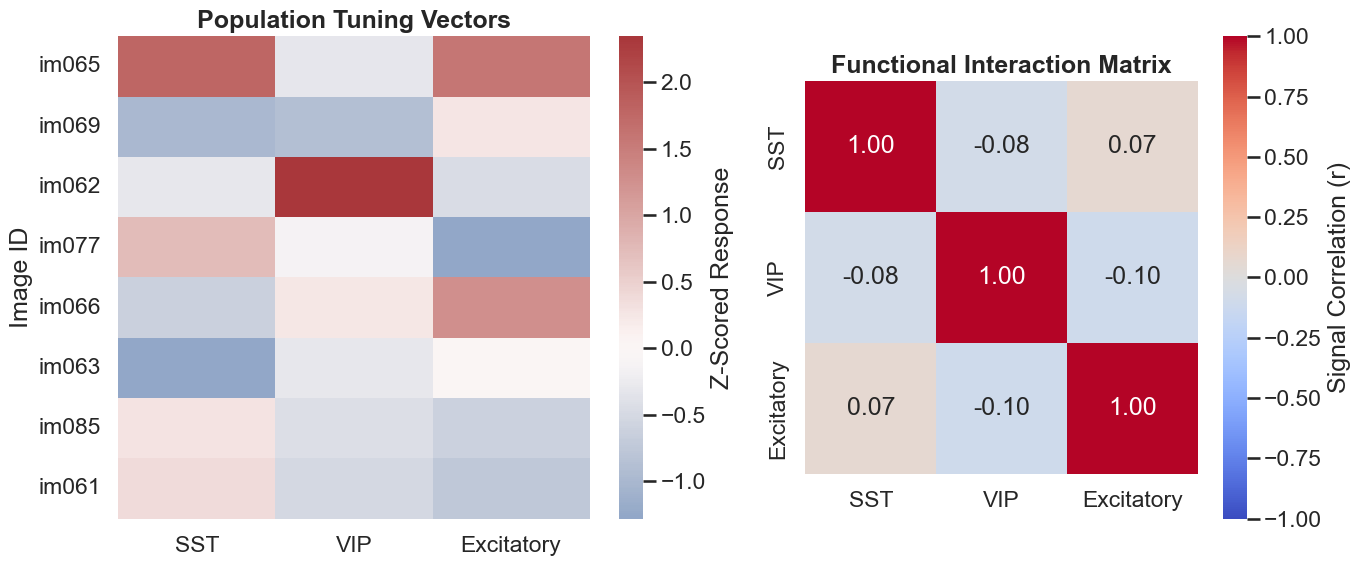

In [19]:
# Q8 "Virtual Interaction" - Signal Correlation Analysis >>>>

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def get_image_tuning_vector(experiment, label):
    """
    Calculates the population mean response to each unique image.
    Returns a Series: Index=ImageName, Value=Mean_dFF
    """
    
    stim_table = experiment.stimulus_presentations
    dff_table = experiment.dff_traces
    timestamps = experiment.ophys_timestamps
    
    # 1. Identify Unique Images
    # We filter out 'omitted' trials
    valid_stims = stim_table[stim_table['omitted'] == False]
    unique_images = valid_stims['image_name'].unique()
    
    # Pre-load all traces to numpy for speed
    all_traces = np.vstack(dff_table['dff'].values)
    
    tuning_vector = {}
    
    for img in unique_images:
        # Get all start times for this specific image
        trials = valid_stims[valid_stims['image_name'] == img]
        
        # We need a robust number of trials
        if len(trials) < 5: continue
            
        # 2. Extract Responses
        # Window: 0 to 0.5s after onset
        img_responses = []
        
        for t_start in trials['start_time']:
            # Create time mask
            t_mask = (timestamps >= t_start) & (timestamps <= t_start + 0.5)
            
            # Extract mean of population for this trial
            if t_mask.any():
                # Mean across Time AND Mean across All Cells
                # shape: (n_cells, n_timepoints) -> single float
                trial_resp = np.mean(all_traces[:, t_mask])
                img_responses.append(trial_resp)
        
        # Average across all trials of this image
        if img_responses:
            tuning_vector[img] = np.mean(img_responses)
            
    return pd.Series(tuning_vector, name=label)



# 1. Build the Interaction Matrix
tuning_vectors = []

if 'q7_experiments' in locals():
    for label, exp in q7_experiments.items():
        print(f"Extracting tuning profile for {label}...")
        vec = get_image_tuning_vector(exp, label)
        tuning_vectors.append(vec)
    
    # Merge into single dtaframe 
    df_interaction = pd.concat(tuning_vectors, axis=1)
    
    # Drop images that weren't shown in all sessions
    df_interaction = df_interaction.dropna()
    
    print(f"Common images found: {len(df_interaction)}")
    
    # 2. Visualization
    if not df_interaction.empty and df_interaction.shape[1] >= 2:
        
        # Setup Figure
        fig = plt.figure(figsize=(14, 6))
        gs = fig.add_gridspec(1, 2, width_ratios=[1.2, 1])
        sns.set_context("talk")
        
        # Panel A: Heatmap of Shared Tuning
        # normalize columns (z-score) to compare patterns, not raw amplitudes!
        df_norm = (df_interaction - df_interaction.mean()) / df_interaction.std()
        
        ax1 = fig.add_subplot(gs[0])
        sns.heatmap(df_norm, cmap="vlag", center=0, ax=ax1, 
                   cbar_kws={'label': 'Z-Scored Response'})
        ax1.set_title("Population Tuning Vectors", fontweight='bold')
        ax1.set_ylabel("Image ID")
        
        # Panel B: Pairwise Correlations 
        ax2 = fig.add_subplot(gs[1])
        
        # Calculate Correlation Matrix
        corr_mat = df_interaction.corr()
        
        # Plot precise values
        sns.heatmap(corr_mat, annot=True, fmt=".2f", cmap="coolwarm", 
                   vmin=-1, vmax=1, square=True, ax=ax2,
                   cbar_kws={'label': 'Signal Correlation (r)'})
        
        ax2.set_title("Functional Interaction Matrix", fontweight='bold')
        
        plt.tight_layout()
        plt.savefig("Q8_Virtual_Interaction_Matrix.png", dpi=300)
        plt.show()
        
    else:
        print("Not enough overlapping data to build model.")
else:
    print("failed")